# Wav2Vec2 — prepoznavanje emocija iz govora (transfer learning)

Klasifikacija emocija na RAVDESS skupu podataka pomoću fine-tuninga pretreniranog transformer modela **Wav2Vec2** (`facebook/wav2vec2-base`). Za razliku od KNN, Naive Bayes i CNN modela, Wav2Vec2 ne uči od nule na RAVDESS-u, već koristi znanje naučeno self-supervised pretreniranjem na velikoj količini govora (Librispeech), i samo se fino podešava (fine-tune) za konkretan zadatak prepoznavanja emocija.

## Ulaz i podela na skupove

Model radi direktno nad sirovim audio signalom (16 kHz, 3 sekunde po zapisu), bez ručno dizajniranih karakteristika ili Mel-spektrograma. Podela na skupove je ista actor-independent podela (16/4/4 glumaca) kao kod ostalih modela, radi doslednog poređenja.

## Fine-tuning

Konvolucioni feature-encoder sloj mreže (nizak nivo audio karakteristika, već dobro naučen na Librispeech-u) je zamrznut — fine-tune-uju se samo transformer sloj i klasifikaciona glava. Ovo smanjuje rizik od overfitting-a na malom RAVDESS skupu i ubrzava trening.

In [ ]:
import os
import inspect
import numpy as np
import pandas as pd
import librosa
import joblib
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer,
)

csv_path = "data/processed_data/audio_labels.csv"
output_dir = "models/wav2vec2"
os.makedirs(output_dir, exist_ok=True)

WAV2VEC2_CHECKPOINT = "facebook/wav2vec2-base"
TARGET_SR = 16000
CLIP_DURATION = 3
EMOTIONS = ["angry", "calm", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

TEST_ACTORS = [21, 22, 23, 24]
VAL_ACTORS = [17, 18, 19, 20]
TRAIN_ACTORS = [a for a in range(1, 25) if a not in TEST_ACTORS + VAL_ACTORS]

def add_noise(data, noise_factor=0.005):
    return data + noise_factor * np.random.randn(len(data))

def time_shift(data, shift_max=0.2):
    shift = np.random.randint(int(len(data) * -shift_max), int(len(data) * shift_max))
    return np.roll(data, shift)

df_labels = pd.read_csv(csv_path)
# audio_labels.csv cuva putanje relativne prema folderu iz kog je pokrenut
# extract_labels.py (obicno "features/"). Ova sveska se pokrece iz korena
# projekta, pa putanje normalizujemo na "data/raw/<Actor_XX>/<fajl>.wav"
# nezavisno od toga odakle je CSV nastao.
df_labels["path"] = df_labels["path"].apply(
    lambda p: os.path.join("data", "raw", *p.replace("\\", "/").split("/")[-2:])
)

train_paths = df_labels[df_labels['actor'].isin(TRAIN_ACTORS)].reset_index(drop=True)
val_paths = df_labels[df_labels['actor'].isin(VAL_ACTORS)].reset_index(drop=True)
test_paths = df_labels[df_labels['actor'].isin(TEST_ACTORS)].reset_index(drop=True)

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC2_CHECKPOINT)
le = LabelEncoder()
le.fit(EMOTIONS)

class RavdessAudioDataset(torch.utils.data.Dataset):
    def __init__(self, df, label_encoder, augment=False):
        self.paths = df['path'].tolist()
        self.labels = label_encoder.transform(df['emotion'].tolist())
        self.augment = augment
        self.target_len = TARGET_SR * CLIP_DURATION

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        y, _ = librosa.load(self.paths[idx], sr=TARGET_SR, duration=CLIP_DURATION, offset=0.5)
        if self.augment:
            choice = np.random.choice(["none", "noise", "shift"])
            if choice == "noise":
                y = add_noise(y)
            elif choice == "shift":
                y = time_shift(y)
        if len(y) < self.target_len:
            y = np.pad(y, (0, self.target_len - len(y)))
        else:
            y = y[:self.target_len]
        inputs = feature_extractor(y, sampling_rate=TARGET_SR, return_tensors="np")
        return {
            "input_values": inputs["input_values"][0].astype(np.float32),
            "labels": int(self.labels[idx]),
        }

train_dataset = RavdessAudioDataset(train_paths, le, augment=True)
val_dataset = RavdessAudioDataset(val_paths, le, augment=False)
test_dataset = RavdessAudioDataset(test_paths, le, augment=False)

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    WAV2VEC2_CHECKPOINT,
    num_labels=len(le.classes_),
    label2id={l: i for i, l in enumerate(le.classes_)},
    id2label={i: l for i, l in enumerate(le.classes_)},
)
model.freeze_feature_encoder()

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

BATCH_SIZE = 4
GRAD_ACCUM = 4
NUM_EPOCHS = 10
steps_per_epoch = max(1, len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM))
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))

ta_params = inspect.signature(TrainingArguments.__init__).parameters
eval_strategy_key = "eval_strategy" if "eval_strategy" in ta_params else "evaluation_strategy"

training_args = TrainingArguments(
    output_dir=os.path.join(output_dir, "checkpoints"),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=3e-5,
    warmup_steps=warmup_steps,
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),
    logging_steps=20,
    report_to="none",
    **{eval_strategy_key: "epoch"},
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


In [ ]:
test_results = trainer.predict(test_dataset)
y_pred = np.argmax(test_results.predictions, axis=1)
y_true = test_results.label_ids

test_acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Wav2Vec2 - Test Confusion Matrix')
plt.savefig(os.path.join(output_dir, "test_confusion_matrix.png"))
plt.show()

trainer.save_model(os.path.join(output_dir, "final_model"))
feature_extractor.save_pretrained(os.path.join(output_dir, "final_model"))
joblib.dump(le, os.path.join(output_dir, "label_encoder.pkl"))


## Rezultati

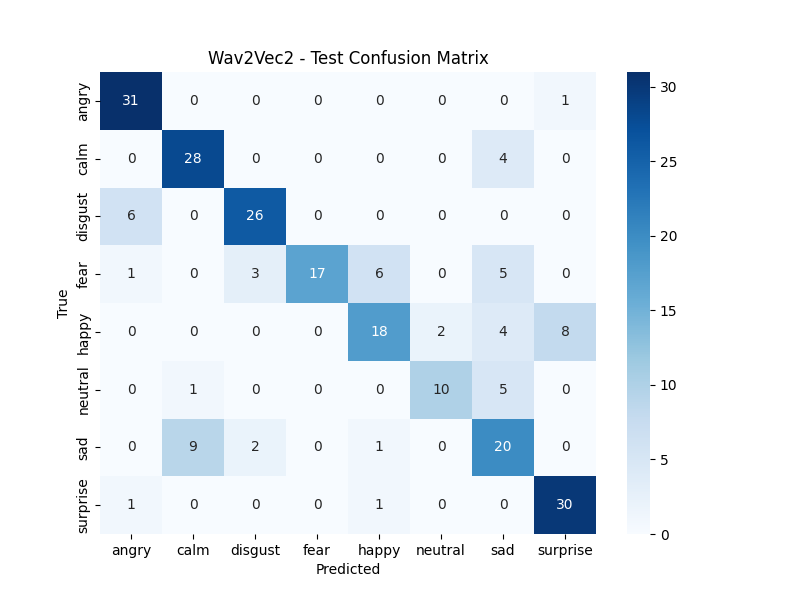

In [2]:
from IPython.display import Image, display
display(Image(filename="models/wav2vec2/test_confusion_matrix.png"))


## Zaključak

Wav2Vec2 model postiže **75.0%** tačnosti na test skupu (actor-independent) — dramatično bolje od sva tri modela trenirana od nule (Naive Bayes 33.3%, KNN 39.2%, CNN 52.1%). Razlika potvrđuje da je količina podataka, ne arhitektura, glavno ograničenje modela treniranih od nule na RAVDESS skupu: Wav2Vec2 zaobilazi to ograničenje koristeći znanje naučeno na mnogo većem, spoljnom skupu govora, i samo ga prilagođava (fine-tune) za konkretan zadatak prepoznavanja emocija.